In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.utils import to_categorical 
from tensorflow.keras.models import load_model, Model
import json
import helper
import plotly.express as px

In [24]:
def avg(group, group_size): 
    group['GroupNumber'] = np.array(range(len(group.index))) // group_size
    res = group.groupby('GroupNumber').mean()
    return res
def load_data(group_size):
    data = pd.read_hdf("../../initialSingleCellDf-channel-20220916-MW_018-001.h5", key="df")
    #print all the columns
    ANTIGENS = ['null', 'E1', 'G4', 'V4', 'T4', 'Q4', 'A2', 'N4']
    data = data.loc[(data.index.get_level_values('CellType') == 'OT-1') & 
                       (data.index.get_level_values('Peptide').isin(ANTIGENS))
                    ]
    data = data.groupby(['Peptide', 'Time', 'Replicate', 'Concentration']).apply(avg, group_size=group_size)
    # antigen = list(data.index.get_level_values('Peptide'))
    # times = list(data.index.get_level_values('Time'))
    # concentration = list(data.index.get_level_values('Concentration'))
    # scaling_factor = 1024/(output_range[1]-output_range[0])
    # X = np.array(data.values)/scaling_factor + output_range[0]
    # y = np.array(list(map(lambda x: ANTIGENS.index(x), antigen)))
    # y = to_categorical(y)
    return data

In [25]:
df= load_data(1)

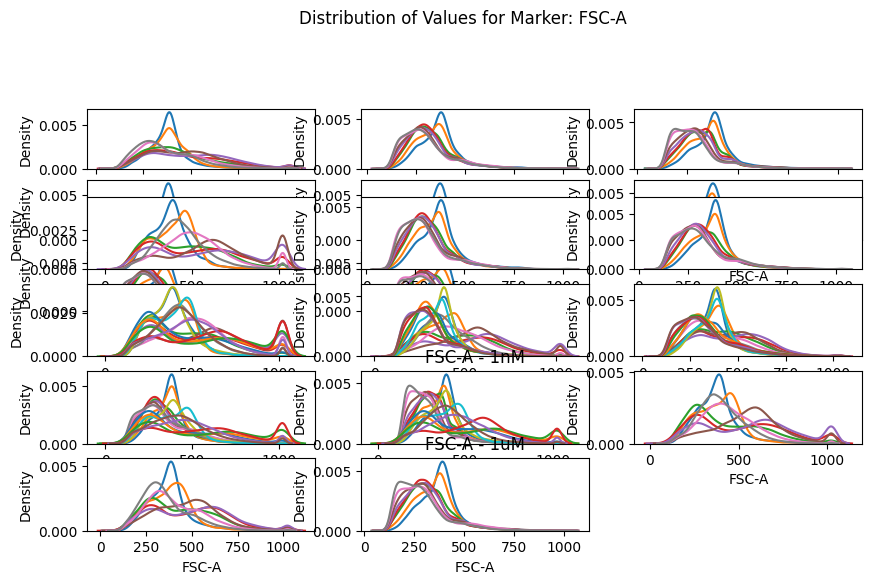

KeyboardInterrupt: 

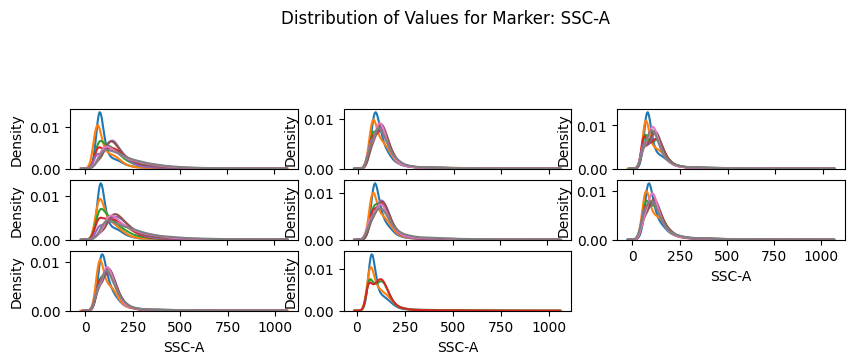

In [33]:
import seaborn as sns
# get the unique times
times = df.index.get_level_values('Time').unique()

# get the unique concentrations
concentrations = df.index.get_level_values('Concentration').unique()

# get the unique antigens
antigens = df.index.get_level_values('Peptide').unique()

# for each antigen-concentration-time, plot the distribution of the values
for marker in df.columns:
    plt.figure(figsize=(10,10))
    plt.suptitle(f'Distribution of Values for Marker: {marker}')
    for i, concentration in enumerate(concentrations):
        for j, antigen in enumerate(antigens):
            plt.subplot(len(antigens)*len(concentration)//3+1,3,i*len(concentration)+j+1)
            for time in times:
                filtered_df = df.loc[(df.index.get_level_values('Time') == time) &
                                (df.index.get_level_values('Concentration') == concentration) &
                                (df.index.get_level_values('Peptide') == antigen)]

                sns.kdeplot(data=filtered_df, x=marker)
        plt.title(f'{marker} - {concentration}')
    plt.show()
